# NASA CMAPSS FD004 Dataset - Data Understanding

## Objective
Build a predictive maintenance system capable of predicting Remaining Useful Life (RUL) of aircraft engines.

## Dataset
NASA CMAPSS FD004

### Characteristics
- Multiple operating conditions
- Multiple fault modes
- Time-series sensor data
- Suitable for predictive maintenance

## Goal
Predict Remaining Useful Life (RUL) for each engine cycle.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
columns = [
    "unit_number",
    "time_cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3"
]

sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

columns.extend(sensor_cols)

print(f"Total Columns: {len(columns)}")
columns

Total Columns: 26


['unit_number',
 'time_cycle',
 'op_setting_1',
 'op_setting_2',
 'op_setting_3',
 'sensor_1',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_5',
 'sensor_6',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_10',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_16',
 'sensor_17',
 'sensor_18',
 'sensor_19',
 'sensor_20',
 'sensor_21']

In [4]:
train_df = pd.read_csv(
    "../data/raw/train_FD004.txt",
    sep=r"\s+",
    header=None
)

train_df = train_df.iloc[:, :26]
train_df.columns = columns

train_df.head()

,unit_number,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [5]:
test_df = pd.read_csv(
    "../data/raw/test_FD004.txt",
    sep=r"\s+",
    header=None
)

test_df = test_df.iloc[:, :26]
test_df.columns = columns

test_df.head()

,unit_number,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,20.0072,0.7000,100.0,491.19,606.67,1481.04,1227.81,9.35,13.60,332.52,2323.67,8704.98,1.07,43.83,313.03,2387.78,8048.98,9.2229,0.02,362,2324,100.00,24.31,14.7007
1,1,2,24.9984,0.6200,60.0,462.54,536.22,1256.17,1031.48,7.05,9.00,174.46,1915.21,7999.94,0.93,36.11,163.61,2028.09,7863.46,10.8632,0.02,306,1915,84.93,14.36,8.5748
2,1,3,42.0000,0.8420,100.0,445.00,549.23,1340.13,1105.88,3.91,5.69,137.34,2211.93,8305.38,1.01,41.52,129.98,2387.95,8071.13,9.3960,0.02,328,2212,100.00,10.39,6.4365
3,1,4,42.0035,0.8402,100.0,445.00,549.19,1339.70,1107.26,3.91,5.69,137.23,2211.89,8301.00,1.01,41.73,129.48,2387.90,8078.89,9.3594,0.02,328,2212,100.00,10.56,6.2367
4,1,5,35.0079,0.8400,100.0,449.44,555.10,1353.04,1117.80,5.48,7.97,192.94,2222.71,8331.05,1.02,41.32,181.82,2387.87,8057.83,9.3030,0.02,333,2223,100.00,14.85,8.9326


In [6]:
rul_df = pd.read_csv(
    "../data/raw/RUL_FD004.txt",
    header=None
)

rul_df.columns = ["RUL"]

rul_df.head()

,RUL
0,22
1,39
2,107
3,75
4,149


In [7]:
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)
print("RUL Shape   :", rul_df.shape)

Train Shape : (61249, 26)
Test Shape  : (41214, 26)
RUL Shape   : (248, 1)


In [8]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit_number   61249 non-null  int64  
 1   time_cycle    61249 non-null  int64  
 2   op_setting_1  61249 non-null  float64
 3   op_setting_2  61249 non-null  float64
 4   op_setting_3  61249 non-null  float64
 5   sensor_1      61249 non-null  float64
 6   sensor_2      61249 non-null  float64
 7   sensor_3      61249 non-null  float64
 8   sensor_4      61249 non-null  float64
 9   sensor_5      61249 non-null  float64
 10  sensor_6      61249 non-null  float64
 11  sensor_7      61249 non-null  float64
 12  sensor_8      61249 non-null  float64
 13  sensor_9      61249 non-null  float64
 14  sensor_10     61249 non-null  float64
 15  sensor_11     61249 non-null  float64
 16  sensor_12     61249 non-null  float64
 17  sensor_13     61249 non-null  float64
 18  sensor_14     61249 non-null  float64

In [9]:
missing_values = train_df.isnull().sum()

missing_values[missing_values > 0]

Series([], dtype: int64)

In [10]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,61249.0,124.325181,71.995350,1.0000,60.0000,126.0000,185.0000,249.0000
time_cycle,61249.0,134.311417,89.783389,1.0000,62.0000,123.0000,191.0000,543.0000
op_setting_1,61249.0,23.999823,14.780722,0.0000,10.0046,25.0014,41.9981,42.0080
op_setting_2,61249.0,0.571347,0.310703,0.0000,0.2507,0.7000,0.8400,0.8420
op_setting_3,61249.0,94.031576,14.251954,60.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,61249.0,472.882435,26.436832,445.0000,445.0000,462.5400,491.1900,518.6700
sensor_2,61249.0,579.420056,37.342647,535.4800,549.3300,555.7400,607.0700,644.4200
sensor_3,61249.0,1417.896600,106.167598,1242.6700,1350.5500,1367.6800,1497.4200,1613.0000
sensor_4,61249.0,1201.915359,119.327591,1024.4200,1119.4900,1136.9200,1302.6200,1440.7700
sensor_5,61249.0,8.031626,3.622872,3.9100,3.9100,7.0500,10.5200,14.6200


In [11]:
num_engines = train_df["unit_number"].nunique()

print(f"Total Engines: {num_engines}")

Total Engines: 249


In [12]:
engine_life = (
    train_df.groupby("unit_number")["time_cycle"]
    .max()
)

engine_life.describe()

count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
Name: time_cycle, dtype: float64

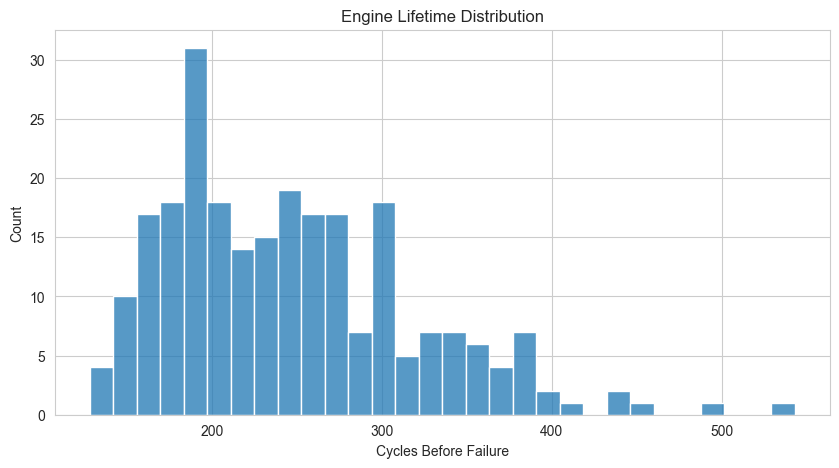

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    engine_life,
    bins=30
)

plt.title("Engine Lifetime Distribution")
plt.xlabel("Cycles Before Failure")
plt.ylabel("Count")

plt.show()

In [14]:
max_cycles = (
    train_df.groupby("unit_number")["time_cycle"]
    .max()
    .reset_index()
)

max_cycles.columns = [
    "unit_number",
    "max_cycle"
]

train_df = train_df.merge(
    max_cycles,
    on="unit_number",
    how="left"
)

train_df["RUL"] = (
    train_df["max_cycle"]
    - train_df["time_cycle"]
)

train_df.head()

,unit_number,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,321,320
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,321,319
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,321,318
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,321,317
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,321,316


In [15]:
engine_1 = train_df[
    train_df["unit_number"] == 1
]

engine_1[
    ["time_cycle", "RUL"]
].tail(10)

,time_cycle,RUL
311,312,9
312,313,8
313,314,7
314,315,6
315,316,5
316,317,4
317,318,3
318,319,2
319,320,1
320,321,0


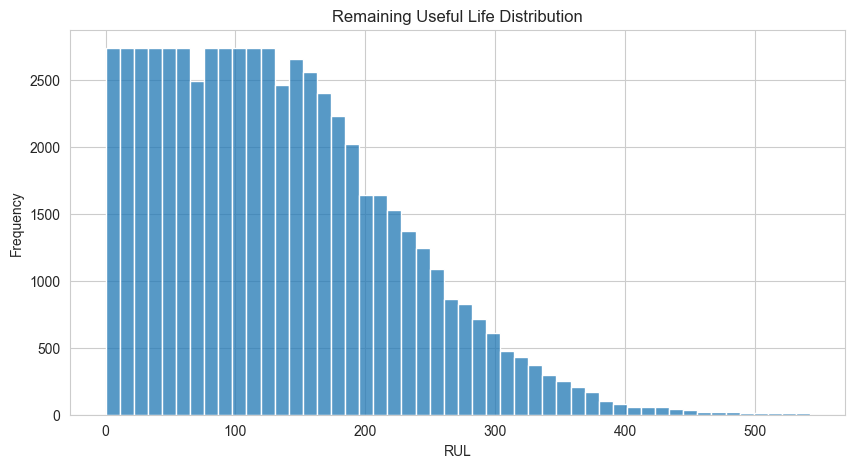

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(
    train_df["RUL"],
    bins=50
)

plt.title("Remaining Useful Life Distribution")
plt.xlabel("RUL")
plt.ylabel("Frequency")

plt.show()

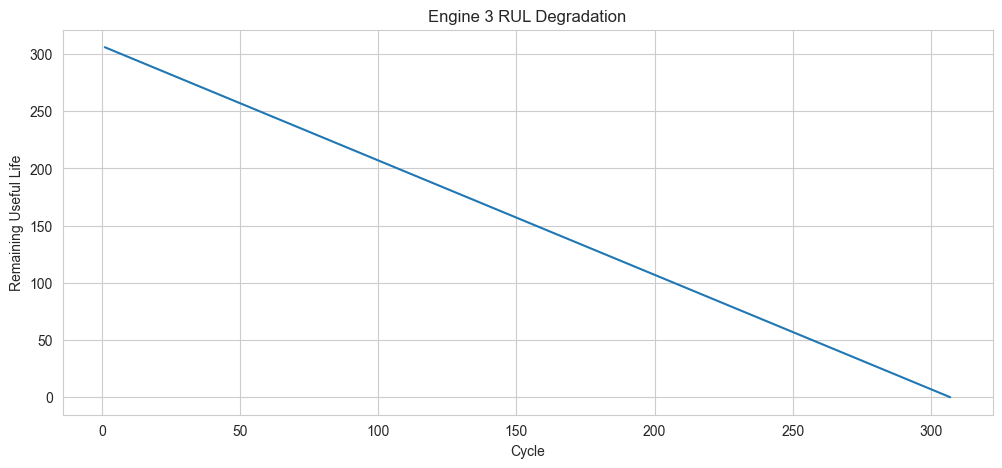

In [17]:
sample_engine = 3

engine_data = train_df[
    train_df["unit_number"] == sample_engine
]

plt.figure(figsize=(12,5))

plt.plot(
    engine_data["time_cycle"],
    engine_data["RUL"]
)

plt.title(
    f"Engine {sample_engine} RUL Degradation"
)

plt.xlabel("Cycle")
plt.ylabel("Remaining Useful Life")

plt.show()

In [18]:
train_df.to_csv(
    "../data/processed/train_with_rul.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


# Key Findings

### Dataset Characteristics
- 249 engines in training set
- 21 sensor measurements
- 3 operating condition settings
- No missing values

### Business Understanding
Each engine gradually degrades over time until failure.

### Machine Learning Problem
Predict Remaining Useful Life (RUL) using operational settings and sensor measurements.

### Next Steps
- Sensor analysis
- Correlation analysis
- Degradation pattern discovery
- Feature engineering
- Predictive maintenance modeling

In [19]:
train_df.shape

(61249, 28)

In [20]:
train_df["RUL"].describe()

count    61249.000000
mean       133.311417
std         89.783389
min          0.000000
25%         61.000000
50%        122.000000
75%        190.000000
max        542.000000
Name: RUL, dtype: float64

In [21]:
train_df.head()

,unit_number,time_cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,max_cycle,RUL
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,5.70,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,321,320
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,13.61,332.10,2323.66,8713.60,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,321,319
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,321,318
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,5.70,137.98,2211.88,8312.35,1.02,41.68,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,321,317
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,9.00,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,321,316
